# FLEURS Dataset Exploration

## 1 Overview

## 2 Importing Libraries

In [1]:
# Importing required libraries
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import unicodedata

from datasets import Audio, load_dataset
from IPython.display import Audio as IPythonAudio, display

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 Loading Dataset

In [2]:
# reproducible selection
SEED = 42

# number of recordings used per language in model evaluation
SAMPLES_PER_LANGUAGE = 200

# FLEURS dataset
DATASET_ID = "google/fleurs"

# languages used in the project
languages = {
    "English": {
        "fleurs_config": "en_us",
        "whisper_language": "en"
    },
    "Malay": {
        "fleurs_config": "ms_my",
        "whisper_language": "ms"
    },
    "Chinese": {
        "fleurs_config": "cmn_hans_cn",
        "whisper_language": "zh"
    },
    "Tamil": {
        "fleurs_config": "ta_in",
        "whisper_language": "ta"
    }
}

In [3]:
# dictionaries for validation and testing datasets
validation_datasets = {}
testing_datasets = {}

# load the original FLEURS validation and test splits
for language, details in languages.items():

    print(f"Loading {language}...")

    validation_datasets[language] = load_dataset(
        DATASET_ID,
        details["fleurs_config"],
        split="validation"
    ).cast_column(
        "audio",
        Audio(decode=False)
    )

    testing_datasets[language] = load_dataset(
        DATASET_ID,
        details["fleurs_config"],
        split="test"
    ).cast_column(
        "audio",
        Audio(decode=False)
    )

Loading English...
Loading Malay...
Loading Chinese...
Loading Tamil...


In [4]:
# number of records in each original split
split_results = []

for language in languages:
    split_results.append({
        "Language": language,
        "Validation Records": len(
            validation_datasets[language]
        ),
        "Testing Records": len(
            testing_datasets[language]
        )
    })

df_splits = pd.DataFrame(split_results)
df_splits

,Language,Validation Records,Testing Records
0,English,394,647
1,Malay,324,749
2,Chinese,409,945
3,Tamil,377,591


## 4 Understanding Dataset Structure

In [5]:
# columns available in each FLEURS dataset
for language in languages:
    print(
        language,
        validation_datasets[language].column_names
    )

English ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Malay ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Chinese ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
Tamil ['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']


In [6]:
# display first five validation transcriptions for each language
for language, dataset in validation_datasets.items():

    print(f"\n{language}")

    sample_records = pd.DataFrame({
        "Transcription": [
            dataset[index]["transcription"]
            for index in range(
                min(5, len(dataset))
            )
        ]
    })

    display(sample_records)


English


,Transcription
0,when you call someone who is thousands of mile...
1,now widely available throughout the archipelag...
2,the u.n. also hopes to finalize a fund to help...
3,then lakkha singh took the lead in singing the...
4,the major religion in moldova is orthodox chri...



Malay


,Transcription
0,saya tidak tahu kalau anda sedar tetapi kebany...
1,penyelidikan dalam al melibatkan pembuatan mes...
2,pandangan yang dibentangkan biasanya sepintas ...
3,banyak format biasa contohnya format dari kelu...
4,sebahagian besar kehidupan keluarga ibrani ber...



Chinese


,Transcription
0,报 告 警 告 称 没 有 人 能 保 证 目 前 在 伊 拉 克 采 取 的 任 何 行 ...
1,因 为 远 离 大 陆 哺 乳 动 物 无 法 长 途 跋 涉 而 来 使 得 巨 龟 成 ...
2,亚 马 逊 河 也 是 地 球 上 最 宽 的 河 流 有 些 河 段 的 宽 度 可 达 ...
3,迦 南 没 有 大 森 林 所 以 木 材 非 常 昂 贵
4,据 警 方 称 撞 倒 摄 影 师 的 汽 车 司 机 未 必 会 面 临 刑 事 指 控



Tamil


,Transcription
0,இந்த விதிகள் திருத்தப்படுவதற்கு முன்னர் அனைத்த...
1,"""கருத்து கேட்டபோது ""விசாரணையின் போது மைக் அதிக..."
2,பூச்சிகளே காற்றில் பறந்த முதல் விலங்குகள் அவற்...
3,சுற்றுச்சூழலுடன் நாம் மிகவும் இணக்கமாக வாழத் த...
4,பல மாவட்டங்கள் சிறிய வசதியான பலமான ஜப்பானிய கோ...


## 5 Sample Recording

In [7]:
# folder for exploration sample
sample_folder = Path(
    "../../data/processed/fleurs_exploration"
)

sample_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [8]:
# use the first English validation recording
sample = validation_datasets["English"][0]

audio_information = sample["audio"]

original_path = Path(
    audio_information["path"]
)

suffix = (
    original_path.suffix
    if original_path.suffix
    else ".wav"
)

sample_path = (
    sample_folder
    / f"sample_english{suffix}"
)

with open(sample_path, "wb") as audio_file:
    audio_file.write(
        audio_information["bytes"]
    )

print(
    "Transcription:",
    sample["transcription"]
)

print(
    "Audio file:",
    sample_path
)

Transcription: when you call someone who is thousands of miles away you are using a satellite
Audio file: ..\..\data\processed\fleurs_exploration\sample_english.wav


In [9]:
# play sample recording
IPythonAudio(
    filename=str(sample_path)
)

## 6 Split and Language Distribution

In [10]:
# validation and testing counts
distribution = pd.DataFrame({
    "Validation": {
        language: len(dataset)
        for language, dataset
        in validation_datasets.items()
    },
    "Testing": {
        language: len(dataset)
        for language, dataset
        in testing_datasets.items()
    }
})

distribution

,Validation,Testing
English,394,647
Malay,324,749
Chinese,409,945
Tamil,377,591


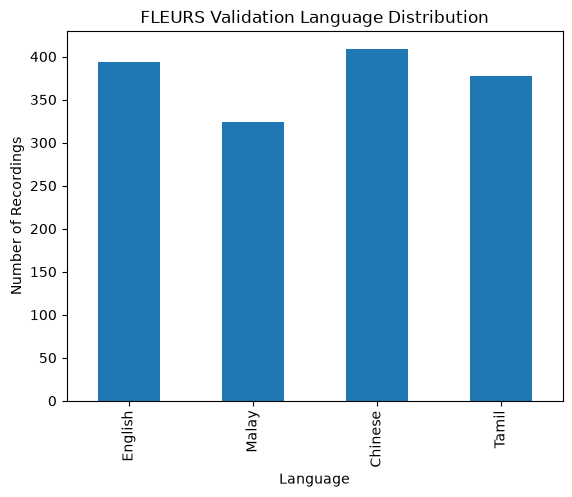

In [11]:
# validation distribution
distribution["Validation"].plot(
    kind="bar"
)

plt.title(
    "FLEURS Validation Language Distribution"
)
plt.xlabel("Language")
plt.ylabel("Number of Recordings")
plt.show()

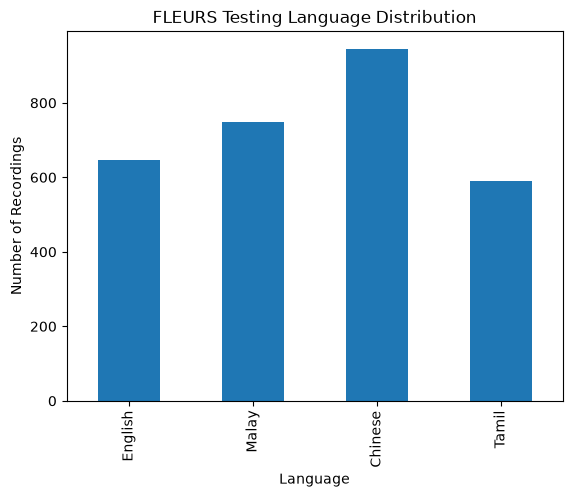

In [12]:
# testing distribution
distribution["Testing"].plot(
    kind="bar"
)

plt.title(
    "FLEURS Testing Language Distribution"
)
plt.xlabel("Language")
plt.ylabel("Number of Recordings")
plt.show()

## 7 Metadata and Transcript

In [13]:
# list for transcript checks
checks = []

for language in languages:

    for split_name, dataset in [
        (
            "Validation",
            validation_datasets[language]
        ),
        (
            "Testing",
            testing_datasets[language]
        )
    ]:

        transcriptions = pd.Series(
            dataset["transcription"],
            dtype="object"
        )

        missing_transcriptions = (
            transcriptions.isnull().sum()
        )

        empty_transcriptions = (
            transcriptions
            .fillna("")
            .astype(str)
            .str.strip()
            .eq("")
            .sum()
        )

        duplicated_transcriptions = (
            transcriptions
            .duplicated()
            .sum()
        )

        missing_audio = sum(
            sample["audio"] is None
            for sample in dataset
        )

        checks.append({
            "Language": language,
            "Split": split_name,
            "Missing Transcriptions":
                missing_transcriptions,
            "Empty Transcriptions":
                empty_transcriptions,
            "Duplicated Transcriptions":
                duplicated_transcriptions,
            "Missing Audio":
                missing_audio
        })

In [14]:
# dataframe for checks
df_checks = pd.DataFrame(checks)
df_checks

,Language,Split,Missing Transcriptions,Empty Transcriptions,Duplicated Transcriptions,Missing Audio
0,English,Validation,0,0,244,0
1,English,Testing,0,0,297,0
2,Malay,Validation,0,0,182,0
3,Malay,Testing,0,0,412,0
4,Chinese,Validation,0,0,259,0
5,Chinese,Testing,0,0,596,0
6,Tamil,Validation,0,0,227,0
7,Tamil,Testing,0,0,255,0


## 8 Evaluation Samples

In [15]:
# select the same reproducible evaluation recordings
validation_selected = {}
testing_selected = {}

for language in languages:

    validation_dataset = (
        validation_datasets[language]
        .shuffle(seed=SEED)
    )

    testing_dataset = (
        testing_datasets[language]
        .shuffle(seed=SEED)
    )

    validation_selected[language] = (
        validation_dataset.select(
            range(
                min(
                    SAMPLES_PER_LANGUAGE,
                    len(validation_dataset)
                )
            )
        )
    )

    testing_selected[language] = (
        testing_dataset.select(
            range(
                min(
                    SAMPLES_PER_LANGUAGE,
                    len(testing_dataset)
                )
            )
        )
    )

In [16]:
# selected evaluation counts
evaluation_split = []

for language in languages:

    evaluation_split.append({
        "Language": language,
        "Validation Records":
            len(validation_selected[language]),
        "Testing Records":
            len(testing_selected[language])
    })

df_evaluation = pd.DataFrame(
    evaluation_split
)

df_evaluation

,Language,Validation Records,Testing Records
0,English,200,200
1,Malay,200,200
2,Chinese,200,200
3,Tamil,200,200


## 9 Evaluation Audio Files

In [17]:
# folder used by Whisper evaluation
processed_folder = Path(
    "../../data/processed/fleurs_whisper"
)

processed_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [18]:
# function for saving selected FLEURS recordings
def save_selected_audio(
    dataset,
    language,
    split_name
):
    config = languages[
        language
    ]["fleurs_config"]

    language_folder = (
        processed_folder
        / split_name
        / config
    )

    language_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    records = []

    for index, sample in enumerate(dataset):

        audio_information = (
            sample["audio"]
        )

        original_path = Path(
            audio_information["path"]
        )

        suffix = (
            original_path.suffix
            if original_path.suffix
            else ".wav"
        )

        audio_path = (
            language_folder
            / f"{index:04d}{suffix}"
        )

        if not audio_path.exists():
            with open(
                audio_path,
                "wb"
            ) as audio_file:
                audio_file.write(
                    audio_information["bytes"]
                )

        records.append({
            "language": language,
            "split": split_name,
            "audio_path":
                audio_path.as_posix(),
            "transcription":
                sample["transcription"]
        })

    return records

In [19]:
# save validation and testing evaluation recordings
audio_records = []

for language in languages:

    audio_records.extend(
        save_selected_audio(
            validation_selected[language],
            language,
            "validation"
        )
    )

    audio_records.extend(
        save_selected_audio(
            testing_selected[language],
            language,
            "test"
        )
    )

audio_df = pd.DataFrame(
    audio_records
)

audio_df.head()

,language,split,audio_path,transcription
0,English,validation,../../data/processed/fleurs_whisper/validation...,technology offers the solution with virtual fi...
1,English,validation,../../data/processed/fleurs_whisper/validation...,there are a lot of social and political effect...
2,English,validation,../../data/processed/fleurs_whisper/validation...,the final score was a one-point victory 21 to ...
3,English,validation,../../data/processed/fleurs_whisper/validation...,inland waterways can be a good theme to base a...
4,English,validation,../../data/processed/fleurs_whisper/validation...,"out of 1,400 people polled prior to the 2010 f..."


In [20]:
# check whether every selected audio file exists and is readable
missing_files = []
unreadable_files = []

for _, row in audio_df.iterrows():

    audio_path = Path(
        row["audio_path"]
    )

    if not audio_path.exists():
        missing_files.append(
            audio_path.as_posix()
        )

    else:
        try:
            sf.info(audio_path)

        except Exception:
            unreadable_files.append(
                audio_path.as_posix()
            )

print(
    "Missing audio files:",
    len(missing_files)
)

print(
    "Unreadable audio files:",
    len(unreadable_files)
)

Missing audio files: 0
Unreadable audio files: 0


## 10 Audio Properties

In [21]:
# audio properties
properties = []

for _, row in audio_df.iterrows():

    audio_path = Path(
        row["audio_path"]
    )

    information = sf.info(
        audio_path
    )

    properties.append({
        "Language": row["language"],
        "Split": row["split"],
        "Sample Rate":
            information.samplerate,
        "Channels":
            information.channels,
        "Format":
            information.format,
        "Duration":
            information.frames
            / information.samplerate
    })

df_properties = pd.DataFrame(
    properties
)

In [22]:
# sample rates
df_properties[
    "Sample Rate"
].value_counts().to_frame(
    "Files"
)

,Files
Sample Rate,
16000,1600


In [23]:
# channels
df_properties[
    "Channels"
].value_counts().to_frame(
    "Files"
)

,Files
Channels,
1,1600


In [24]:
# formats
df_properties[
    "Format"
].value_counts().to_frame(
    "Files"
)

,Files
Format,
WAV,1600


In [25]:
# recording durations
df_properties[
    "Duration"
].describe().to_frame()

,Duration
count,1600.000000
mean,11.097638
std,4.420536
min,2.700000
25%,8.070000
50%,10.320000
75%,13.260000
max,50.880000


In [26]:
# duration by language
df_properties.groupby(
    "Language"
)["Duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Language,,,,,,,,
Chinese,400.0,11.40030,4.360302,3.30,8.22,10.44,14.145,27.72
English,400.0,9.74175,3.450658,2.70,7.20,9.30,11.520,29.30
Malay,400.0,10.67115,3.535880,4.26,8.10,10.20,12.840,26.28
Tamil,400.0,12.57735,5.529693,3.48,9.12,11.45,14.895,50.88


## 11 Saving Evaluation Metadata

In [27]:
# function used in the Whisper evaluation notebook
def normalise_text(text):

    text = unicodedata.normalize(
        "NFKC",
        str(text)
    ).lower()

    text = "".join(
        character
        if character.isalnum()
        or character.isspace()
        else " "
        for character in text
    )

    text = " ".join(
        text.split()
    )

    return text.strip()

In [28]:
# add the normalised reference used during Whisper evaluation
audio_df[
    "reference"
] = audio_df[
    "transcription"
].apply(
    normalise_text
)

audio_df.head()

,language,split,audio_path,transcription,reference
0,English,validation,../../data/processed/fleurs_whisper/validation...,technology offers the solution with virtual fi...,technology offers the solution with virtual fi...
1,English,validation,../../data/processed/fleurs_whisper/validation...,there are a lot of social and political effect...,there are a lot of social and political effect...
2,English,validation,../../data/processed/fleurs_whisper/validation...,the final score was a one-point victory 21 to ...,the final score was a one point victory 21 to ...
3,English,validation,../../data/processed/fleurs_whisper/validation...,inland waterways can be a good theme to base a...,inland waterways can be a good theme to base a...
4,English,validation,../../data/processed/fleurs_whisper/validation...,"out of 1,400 people polled prior to the 2010 f...",out of 1 400 people polled prior to the 2010 f...


In [29]:
# save validation and testing metadata
metadata_folder = (
    processed_folder
    / "metadata"
)

metadata_folder.mkdir(
    parents=True,
    exist_ok=True
)

validation_metadata = (
    audio_df[
        audio_df["split"]
        == "validation"
    ]
    .reset_index(drop=True)
)

testing_metadata = (
    audio_df[
        audio_df["split"]
        == "test"
    ]
    .reset_index(drop=True)
)

validation_metadata.to_csv(
    metadata_folder
    / "validation.csv",
    index=False
)

testing_metadata.to_csv(
    metadata_folder
    / "testing.csv",
    index=False
)

In [30]:
print(
    "Validation metadata saved:",
    (
        metadata_folder
        / "validation.csv"
    ).exists()
)

print(
    "Testing metadata saved:",
    (
        metadata_folder
        / "testing.csv"
    ).exists()
)

Validation metadata saved: True
Testing metadata saved: True


## 12 Conclusion